In [1]:
import numpy as np
import pandas as pd
import time
import math
import glob
import re
import scipy.optimize
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from numba import njit
from joblib import Parallel, delayed
import keras
from keras.models import Sequential, load_model
from keras.layers import Dense, InputLayer
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import ipywidgets as widgets
from ipywidgets import interact
%matplotlib inline

# ==========================================
# 🛑 LE PARAMÈTRE MAÎTRE 🛑
# ==========================================
# True  = Regénérer les données Monte Carlo et ré-entraîner le réseau (Prend du temps)
# False = Charger les données CSV et le modèle Keras existants (Instantané)
FIT_MODE = True

# Variables Globales du modèle Rough Bergomi
maturities = np.array([0.1, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.0])
strikes = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5])
strikes_dim = len(strikes)
maturities_dim = len(maturities)

# Bornes des 11 paramètres (8 xi, nu, rho, H)
# Nouvelles bornes beaucoup plus larges pour encaisser le S&P 500 en crise
# xi passe à 0.60 max, nu (vol of vol) monte à 5.0
ub = [0.60, 0.60, 0.60, 0.60, 0.60, 0.60, 0.60, 0.60, 5.0, 0.0, 0.5]
lb = [0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.3, -1.0, 0.025]



In [2]:
# Fonctions Black-Scholes optimisées pour Numba
@njit(fastmath=True, cache=True)
def norm_cdf(x):
    return 0.5 * (1.0 + math.erf(x / 1.4142135623730951))

@njit(fastmath=True, cache=True)
def bs_call_price_numba(S, K, T, r, vol):
    d1 = (math.log(S / K) + (r + 0.5 * vol**2) * T) / (vol * math.sqrt(T))
    d2 = d1 - vol * math.sqrt(T)
    return S * norm_cdf(d1) - K * math.exp(-r * T) * norm_cdf(d2)

@njit(fastmath=True, cache=True)
def implied_volatility_numba(target_price, S, K, T, r=0.0):
    intrinsic = max(S - K, 0.0)
    if target_price <= intrinsic: return 0.001
    low, high = 1e-3, 3.0
    for _ in range(50):
        mid = (low + high) / 2.0
        if bs_call_price_numba(S, K, T, r, mid) > target_price:
            high = mid
        else:
            low = mid
    return (low + high) / 2.0

@njit(fastmath=True, cache=True)
def rough_bergomi_mc_pricer(params, maturities, strikes, S0=1.0, paths=10000, steps_per_year=100):
    xi_array = params[:8]
    nu, rho, H = params[8], params[9], params[10]
    
    T_max = maturities[-1]
    total_steps = int(T_max * steps_per_year)
    dt = T_max / total_steps
    time_grid = np.zeros(total_steps)
    for i in range(total_steps): time_grid[i] = dt * (i + 1)

    xi_t = np.zeros(total_steps)
    for i in range(total_steps):
        bucket_idx = np.searchsorted(maturities, time_grid[i])
        if bucket_idx >= len(xi_array): bucket_idx = len(xi_array) - 1
        xi_t[i] = xi_array[bucket_idx]

    dZ = np.random.normal(0.0, math.sqrt(dt), (paths, total_steps))
    dW_perp = np.random.normal(0.0, math.sqrt(dt), (paths, total_steps))
    dW = rho * dZ + math.sqrt(1.0 - rho**2) * dW_perp

    Y = np.zeros((paths, total_steps))
    gamma_kernel = np.zeros(total_steps)
    for k in range(1, total_steps + 1):
        gamma_kernel[k-1] = ((k - 0.5) * dt)**(H - 0.5)

    sqrt_2H = math.sqrt(2.0 * H)
    for p in range(paths):
        for i in range(total_steps):
            sum_Z = 0.0
            for k in range(i + 1):
                sum_Z += dZ[p, k] * gamma_kernel[i - k]
            Y[p, i] = sqrt_2H * sum_Z

    t_2H = np.zeros(total_steps)
    for i in range(total_steps): t_2H[i] = time_grid[i]**(2.0 * H)
        
    V = np.zeros((paths, total_steps))
    for i in range(total_steps):
        for p in range(paths):
            V[p, i] = xi_t[i] * math.exp(nu * Y[p, i] - 0.5 * (nu**2) * t_2H[i])

    X = np.zeros((paths, total_steps + 1))
    for i in range(total_steps):
        for p in range(paths):
            X[p, i+1] = X[p, i] + -0.5 * V[p, i] * dt + math.sqrt(V[p, i]) * dW[p, i]

    S = np.zeros((paths, total_steps + 1))
    for p in range(paths):
        for i in range(total_steps + 1):
            S[p, i] = S0 * math.exp(X[p, i])

    for i in range(1, total_steps + 1):
        mean_S = np.mean(S[:, i])
        for p in range(paths): S[p, i] = S[p, i] * (S0 / mean_S)

    vol_grid = np.zeros((len(maturities), len(strikes)))
    for i in range(len(maturities)):
        T = maturities[i]
        step_idx = int(T * steps_per_year)
        S_T = S[:, step_idx]
        for j in range(len(strikes)):
            K = strikes[j]
            mc_price = 0.0
            for p in range(paths): mc_price += max(S_T[p] - K, 0.0)
            mc_price /= paths
            vol_grid[i, j] = implied_volatility_numba(mc_price, S0, K, T, 0.0)

    return vol_grid

def simulate_single_scenario(current_params, maturities, strikes):
    return rough_bergomi_mc_pricer(current_params, maturities, strikes, S0=1.0, paths=15000, steps_per_year=100).flatten()

In [3]:
if FIT_MODE:
    print("🔥 FIT_MODE = True : Génération de 40 000 échantillons en cours...")
    num_samples = 40000
    X_parameters = np.random.uniform(lb, ub, size=(num_samples, 11))
    
    # Warmup Numba
    _ = simulate_single_scenario(X_parameters[0], maturities, strikes)
    
    start_time = time.time()
    Y_volatilities = Parallel(n_jobs=-1, verbose=10, batch_size=50)(
        delayed(simulate_single_scenario)(X_parameters[i], maturities, strikes)
        for i in range(num_samples)
    )
    print(f"✅ Simulation terminée en {time.time() - start_time:.2f} secondes !")
    
    param_columns = [f'xi_{m}' for m in maturities] + ['nu', 'rho', 'H']
    vol_columns = [f'vol_T{t}_K{k}' for t in maturities for k in strikes]
    dataset = pd.concat([pd.DataFrame(X_parameters, columns=param_columns), 
                         pd.DataFrame(Y_volatilities, columns=vol_columns)], axis=1)
    dataset.to_csv("rough_bergomi_training_data_optim.csv", index=False)
    print("💾 Données sauvegardées.")
else:
    print("⚡ FIT_MODE = False : Chargement des données existantes...")
    dataset = pd.read_csv("rough_bergomi_training_data_optim.csv")
    print(f"✅ {len(dataset)} échantillons chargés.")

# --- PRÉPARATION DES DONNÉES (Exécuté dans les deux cas) ---
X = dataset.iloc[:, :11].values
Y = dataset.iloc[:, 11:].values

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.15, random_state=42)

def myscale(x):
    res = np.zeros(11)
    for i in range(11): res[i] = (x[i] - (ub[i] + lb[i])*0.5) * 2 / (ub[i] - lb[i])
    return res

def myinverse(x):
    res = np.zeros(11)
    for i in range(11): res[i] = x[i] * (ub[i] - lb[i]) * 0.5 + (ub[i] + lb[i]) * 0.5
    return res

x_train_transform = np.array([myscale(x) for x in x_train])
x_test_transform = np.array([myscale(x) for x in x_test])

scale2 = StandardScaler()
y_train_transform = scale2.fit_transform(y_train)
y_test_transform = scale2.transform(y_test)

def xinversetransform(x):
    return scale2.inverse_transform(x.reshape(1, -1))[0]

🔥 FIT_MODE = True : Génération de 40 000 échantillons en cours...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   18.6s
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:   19.4s
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done 424 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done 874 tasks      | elapsed:  4.6min
[Parallel(n_jobs=-1)]: Done 1324 tasks      | elapsed:  6.8min
[Parallel(n_jobs=-1)]: Done 1874 tasks      | elapsed:  9.4min
[Parallel(n_jobs=-1)]: Done 2424 tasks      | elapsed:  9.5min
[Parallel(n_jobs=-1)]: Done 3074 tasks      | elapsed: 14.8min
[Parallel(n_jobs=-1)]: Done 3724 tasks      | elapsed: 17.4min
[Parallel(n_jobs=-1)]: Done 4474 tasks      | elapsed: 19.9min
[Parallel(n_jobs=-1)]: Done 5224 tasks      | elapsed: 22.4min
[Parallel(n_jobs=-1)]: Done 6074 tasks      | elapsed: 27.4min
[Parallel(n_jobs=-1)]: Done 6924 tasks      | elapsed: 30.2min
[Parallel(n_jobs=-1)]: Done 7874 tasks      | 

✅ Simulation terminée en 10605.35 secondes !
💾 Données sauvegardées.


In [4]:
if FIT_MODE:
    print("🔥 FIT_MODE = True : Création et entraînement du Réseau de Neurones...")
    modelGEN = Sequential([
        InputLayer(input_shape=(11,)),
        Dense(30, activation='elu'),
        Dense(30, activation='elu'),
        Dense(30, activation='elu'),
        Dense(30, activation='elu'),
        Dense(88, activation='linear')
    ])
    
    modelGEN.compile(loss="mse", optimizer="adam")
    earlystop = EarlyStopping(monitor="val_loss", min_delta=0, patience=25, verbose=1, mode="min")
    
    modelGEN.fit(x_train_transform, y_train_transform, batch_size=32,
                 validation_data=(x_test_transform, y_test_transform),
                 epochs=500, verbose=True, shuffle=True, callbacks=[earlystop])
    
    modelGEN.save("my_rough_bergomi_model.keras")
    print("💾 Modèle sauvegardé sous 'my_rough_bergomi_model.keras'.")
else:
    print("⚡ FIT_MODE = False : Chargement du réseau de neurones pré-entraîné...")
    modelGEN = load_model("my_rough_bergomi_model.keras")
    print("✅ Modèle chargé avec succès.")

modelGEN.summary()

🔥 FIT_MODE = True : Création et entraînement du Réseau de Neurones...


c:\Users\ERWAN\anaconda3\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/500
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.1481 - val_loss: 0.0425
Epoch 2/500
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0316 - val_loss: 0.0259
Epoch 3/500
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0225 - val_loss: 0.0205
Epoch 4/500
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0189 - val_loss: 0.0177
Epoch 5/500
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0170 - val_loss: 0.0161
Epoch 6/500
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0158 - val_loss: 0.0162
Epoch 7/500
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0149 - val_loss: 0.0152
Epoch 8/500
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0143 - val_loss: 0.0140
Epoch 9/500
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0138 - val_loss: 0.0138
Epoch 10/500
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0133 - val_loss: 0.0137
Epoch 11/500
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0129 - val_loss: 0.0127
Epoch 12/500
1063/

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 88)             │         2,728 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,636 (68.89 KB)

 Trainable params: 5,878 (22.96 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 11,758 (45.93 KB)

In [5]:
# Extraction des poids pour le Levenberg-Marquardt
NNParameters = []
for layer in modelGEN.layers:
    weights = layer.get_weights()
    if len(weights) > 0: 
        NNParameters.append(weights)

def elu(x):
    return np.where(x > 0, x, np.exp(x) - 1)

def elu_prime(x):
    return np.where(x > 0, 1, np.exp(x))

def NeuralNetwork(x):
    input1 = x
    for i in range(4): # 4 hidden layers
        input1 = np.dot(input1, NNParameters[i][0]) + NNParameters[i][1]
        input1 = elu(input1)
    # Output layer
    return np.dot(input1, NNParameters[4][0]) + NNParameters[4][1]

def NeuralNetworkGradient(x):
    input1 = x
    Z_list = []
    
    # --- Passe avant (Forward Pass) ---
    for i in range(4):
        Z = np.dot(input1, NNParameters[i][0]) + NNParameters[i][1]
        Z_list.append(Z)
        input1 = elu(Z)
        
    # --- Passe arrière (Chain Rule / Backprop) ---
    # On initialise le gradient avec les poids de la dernière couche (taille 30x88)
    grad = NNParameters[4][0] 
    
    for i in range(3, -1, -1):
        # da_dz a une taille (30,)
        da_dz = elu_prime(Z_list[i]) 
        
        # On force numpy à multiplier chaque LIGNE de grad par l'élément de da_dz correspondant
        scaled_grad = da_dz[:, np.newaxis] * grad 
        
        # On multiplie par la matrice de poids de la couche en cours
        grad = np.dot(NNParameters[i][0], scaled_grad)
        
    # Le résultat final a une forme parfaite de (11, 88)
    return grad

In [ ]:
def plot_func(xi0, nu, rho, H):
    full_params = np.array([xi0]*8 + [nu, rho, H])
    x0 = myscale(full_params)
    Smiles = xinversetransform(NeuralNetwork(x0))
    
    plt.figure(1,figsize=(14,12))
    for i in range(8):
        plt.subplot(4,4,i+1)
        plt.plot(np.log(strikes/1), Smiles[i*strikes_dim:(i+1)*strikes_dim], '*b', label=" NN Approx")
        plt.ylim(0.1,0.8)
        plt.title(f"Maturity={maturities[i]:.2f}")
        plt.xlabel("log-moneyness")
        plt.ylabel("Implied vol")
        plt.legend()
    plt.tight_layout()
    plt.show()

interact(plot_func, 
         xi0 = widgets.FloatSlider(value=0.04, min=0.01, max=0.16, step=0.01),
         nu  = widgets.FloatSlider(value=2.0, min=0.3, max=4.0, step=0.1),
         rho = widgets.FloatSlider(value=-0.7, min=-0.95, max=-0.1, step=0.05),
         H   = widgets.FloatSlider(value=0.1, min=0.025, max=0.5, step=0.05))

interactive(children=(FloatSlider(value=0.04, description='xi0', max=0.16, min=0.01, step=0.01), FloatSlider(v…

<function __main__.plot_func(xi0, nu, rho, H)>

In [7]:
def parse_french_date(date_str):
    fr_to_en = {'janvier': 'january', 'février': 'february', 'mars': 'march', 'avril': 'april', 
                'mai': 'may', 'juin': 'june', 'juillet': 'july', 'août': 'august', 
                'septembre': 'september', 'octobre': 'october', 'novembre': 'november', 'décembre': 'december'}
    date_str = date_str.lower()
    for fr, en in fr_to_en.items(): date_str = date_str.replace(fr, en)
    return pd.to_datetime(date_str)

grid_T, grid_K = np.meshgrid(maturities, strikes)
vol_columns = [f'vol_T{t}_K{k}' for t in maturities for k in strikes]

file_list = glob.glob("spx_quotedata_*.csv")
print(f"Extraction des données marché ({len(file_list)} fichiers trouvés)...")

all_raw_data = []
for file in file_list:
    try:
        with open(file, 'r', encoding='utf-8') as f:
            header_text = "".join([f.readline() for _ in range(5)])
        S0 = float(re.search(r'Last:\s*([\d\.]+)', header_text).group(1))
        quote_date = parse_french_date(re.search(r'Date:\s*(.*?)\s*(?:à|,)', header_text).group(1).strip())
        
        df = pd.read_csv(file, skiprows=3)
        df['T'] = (pd.to_datetime(df['Expiration Date']) - quote_date).dt.days / 365.25
        df['Moneyness'] = df['Strike'] / S0
        put_iv_col = 'IV.1' if 'IV.1' in df.columns else df.columns[-5]
        df['Target_IV'] = np.where(df['Strike'] < S0, df[put_iv_col], df['IV'])
        
        clean_data = df[(df['Target_IV'] > 0) & (df['T'] > 0.02)].copy()
        clean_data['Quote_Date'] = quote_date
        clean_data['Spot'] = S0
        all_raw_data.append(clean_data)
    except: pass

master_dataset = []
if all_raw_data:
    master_raw_df = pd.concat(all_raw_data, ignore_index=True)
    for quote_date, group in master_raw_df.groupby('Quote_Date'):
        S0 = group['Spot'].mean()
        points, values = group[['T', 'Moneyness']].values, group['Target_IV'].values
        
        # Interpolation 2D robuste
        interp_linear = griddata(points, values, (grid_T, grid_K), method='linear')
        interp_nearest = griddata(points, values, (grid_T, grid_K), method='nearest')
        interpolated_surface = np.where(np.isnan(interp_linear), interp_nearest, interp_linear).T
        
        market_target_88 = interpolated_surface.flatten()
        if not np.isnan(market_target_88).any():
            daily_record = {'Date': quote_date, 'Spot': S0}
            for col_name, vol_val in zip(vol_columns, market_target_88): daily_record[col_name] = vol_val
            master_dataset.append(daily_record)

    if master_dataset:
        pd.DataFrame(master_dataset).sort_values('Date').to_csv("SPX_Historical_8x11_Surfaces.csv", index=False)
        print("✅ Données marché traitées et sauvegardées !")

Extraction des données marché (19 fichiers trouvés)...
✅ Données marché traitées et sauvegardées !


In [9]:
try:
    real_market_df = pd.read_csv("SPX_Historical_8x11_Surfaces.csv")
    real_vols = real_market_df.iloc[0, 2:].values.astype(float)
    
    # On utilise le scale2 déjà fitté en Cellule 3 !
    real_vols_scaled = scale2.transform(real_vols.reshape(1, -1))[0]

    def CostFuncLS_Market(x): return (NeuralNetwork(x) - real_vols_scaled)
    def JacobianLS_Market(x): return NeuralNetworkGradient(x).T

        # On enferme le solveur strictement dans l'espace que le réseau a appris [-1, 1]
    bounds_nn = (-1.0, 1.0) 
    init_guess = np.zeros(11)

        # On utilise la méthode 'trf' (Trust Region Reflective) qui gère les bornes
    result = scipy.optimize.least_squares(
            CostFuncLS_Market, 
            init_guess, 
            JacobianLS_Market, 
            bounds=bounds_nn,   # <--- LE FIX EST LÀ
            method='trf',       # <--- NÉCESSAIRE QUAND ON MET DES BORNES
            gtol=1E-10
        )
    calibrated_params = myinverse(result.x)

    print("\n✅ CALIBRATION RÉUSSIE !")
    print(f"Date du Marché : {real_market_df['Date'].iloc[0]}")
    print(f"S&P 500 Spot   : {real_market_df['Spot'].iloc[0]:.2f}")
    print("=" * 40)
    print(f"H   (Hurst)   = {calibrated_params[10]:.4f}  <-- Si < 0.15, la volatilité est rough!")
    print(f"nu  (VolVol)  = {calibrated_params[8]:.4f}")
    print(f"rho (Correl)  = {calibrated_params[9]:.4f}")
    print("-" * 40)
    for i, t in enumerate(maturities):
        print(f"  xi({t} ans) = {calibrated_params[i]:.4f}")

except FileNotFoundError:
    print("⚠️ Fichier 'SPX_Historical_8x11_Surfaces.csv' non trouvé. Vérifiez que la cellule 7 a fonctionné avec vos fichiers CBOE.")


✅ CALIBRATION RÉUSSIE !
Date du Marché : 2026-04-10
S&P 500 Spot   : 6824.66
H   (Hurst)   = 0.2212  <-- Si < 0.15, la volatilité est rough!
nu  (VolVol)  = 2.7628
rho (Correl)  = -0.6880
----------------------------------------
  xi(0.1 ans) = 0.0170
  xi(0.3 ans) = 0.0607
  xi(0.6 ans) = 0.3195
  xi(0.9 ans) = 0.6000
  xi(1.2 ans) = 0.6000
  xi(1.5 ans) = 0.6000
  xi(1.8 ans) = 0.6000
  xi(2.0 ans) = 0.5477


📉 QUALITÉ DU FIT (ERREUR DE RE-PRICING) :
Erreur Moyenne Absolue (MAE) : 16.49 points de pourcentage de volatilité
Erreur Quadratique (RMSE)    : 21.07 points de pourcentage de volatilité


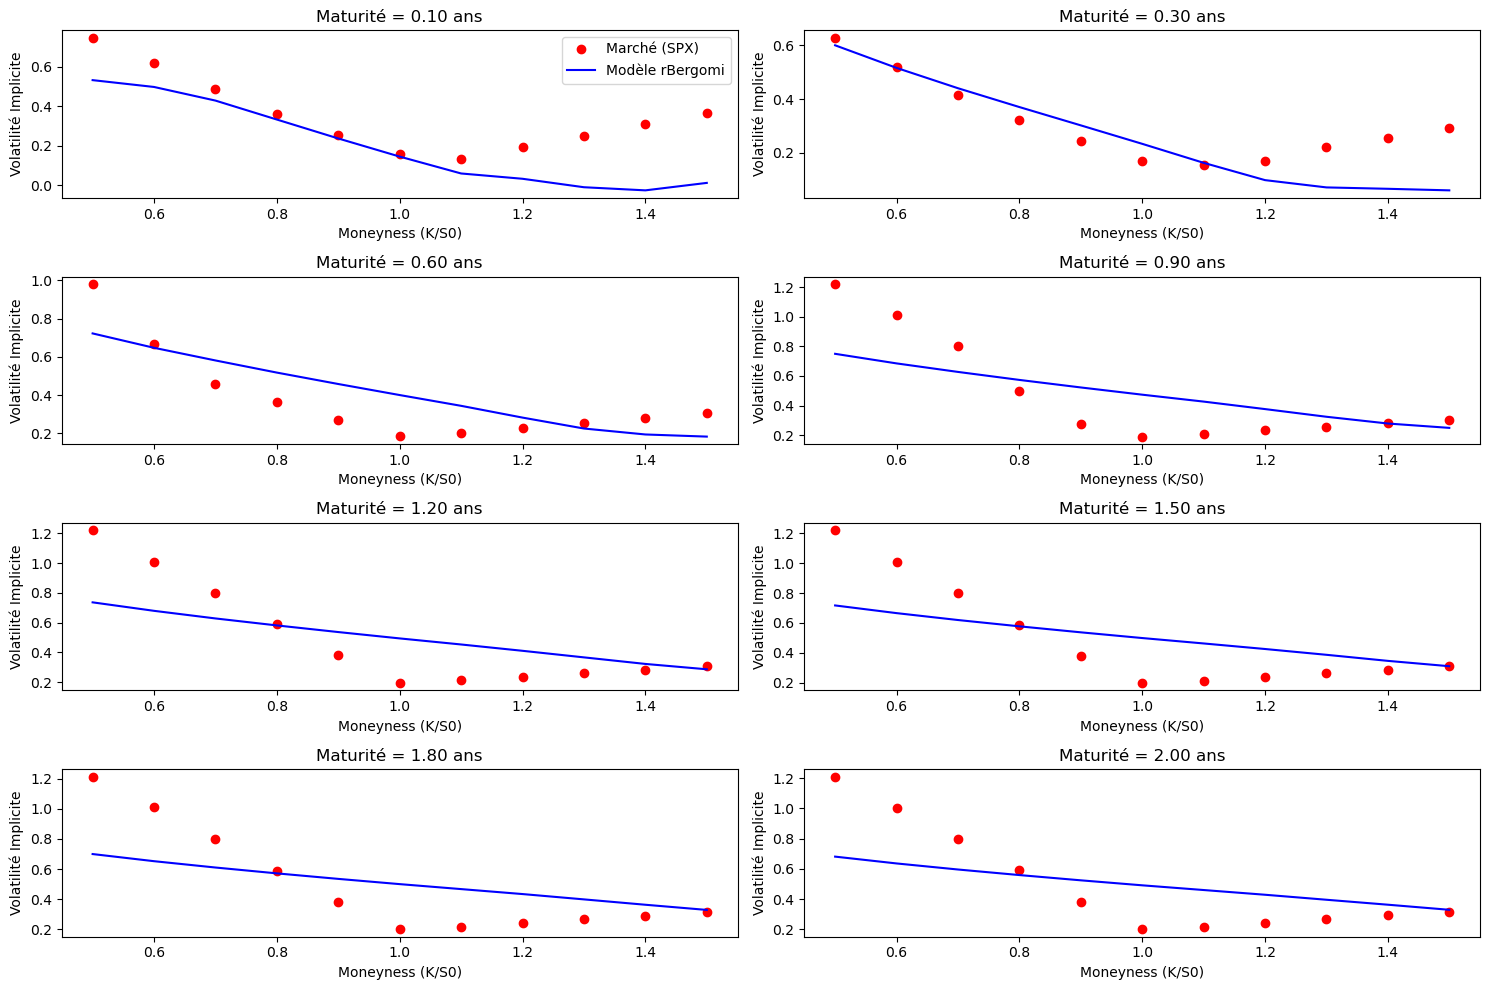

In [10]:
# 1. Prédiction du modèle avec vos paramètres calibrés
# On rescale les paramètres pour les passer au réseau
params_scaled = myscale(calibrated_params)
predicted_vols_scaled = NeuralNetwork(params_scaled)

# On ramène les prédictions à leur vraie échelle (en volatilité pure)
predicted_vols = xinversetransform(predicted_vols_scaled)
market_vols = real_vols # Vos vraies données du marché

# 2. Calcul des erreurs
mae = np.mean(np.abs(predicted_vols - market_vols))
rmse = np.sqrt(np.mean((predicted_vols - market_vols)**2))

print(f"📉 QUALITÉ DU FIT (ERREUR DE RE-PRICING) :")
print(f"Erreur Moyenne Absolue (MAE) : {mae*100:.2f} points de pourcentage de volatilité")
print(f"Erreur Quadratique (RMSE)    : {rmse*100:.2f} points de pourcentage de volatilité")

# 3. Visualisation : Marché vs Modèle
plt.figure(figsize=(15, 10))
for i in range(8):
    plt.subplot(4, 2, i+1)
    # Les 11 points du marché en ROUGE
    plt.plot(strikes, market_vols[i*11:(i+1)*11], 'or', label="Marché (SPX)")
    # La courbe du modèle Rough Bergomi en BLEU
    plt.plot(strikes, predicted_vols[i*11:(i+1)*11], '-b', label="Modèle rBergomi")
    
    plt.title(f"Maturité = {maturities[i]:.2f} ans")
    plt.xlabel("Moneyness (K/S0)")
    plt.ylabel("Volatilité Implicite")
    if i == 0: plt.legend()

plt.tight_layout()
plt.show()

In [12]:
# Test : Prenons le milieu de ce que le réseau connaît
test_params = np.array([0.08]*8 + [2.0, -0.7, 0.1])
pred_vols = xinversetransform(NeuralNetwork(myscale(test_params)))

print(f"Volatilité moyenne du réseau : {np.mean(pred_vols)*100:.2f}%")
print(f"Volatilité moyenne du marché : {np.mean(real_vols)*100:.2f}%")

Volatilité moyenne du réseau : 31.15%
Volatilité moyenne du marché : 44.09%
